In [2]:
from google.colab import files
upload =files.upload()
import matplotlib.pyplot as plt


Saving insurance.csv to insurance.csv


In [3]:
import numpy as np
import pandas as pd

# EDA :
Understanding the Data


In [4]:
df=pd.read_csv("insurance.csv")

In [5]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [7]:
df.shape

(1338, 7)

In [8]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [9]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [10]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [11]:
import seaborn as sns

<Axes: xlabel='children', ylabel='count'>

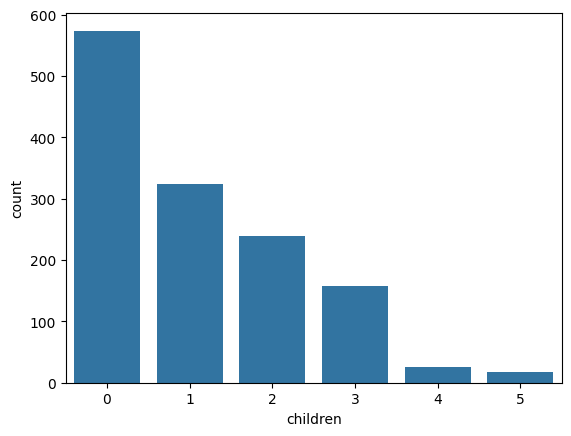

In [12]:
sns.countplot(x=df['children'])

/tmp/ipykernel_1437/267766752.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['region'],palette='dark')


<Axes: xlabel='region', ylabel='count'>

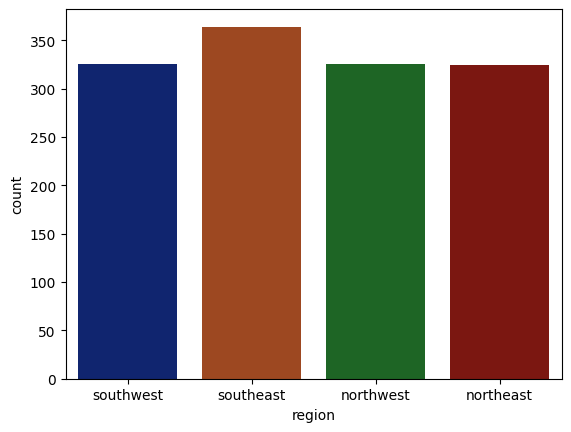

In [13]:
sns.countplot(x=df['region'],palette='dark')

In [14]:
df.columns


Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [15]:
numeric_cols=['age', 'bmi', 'children','charges']

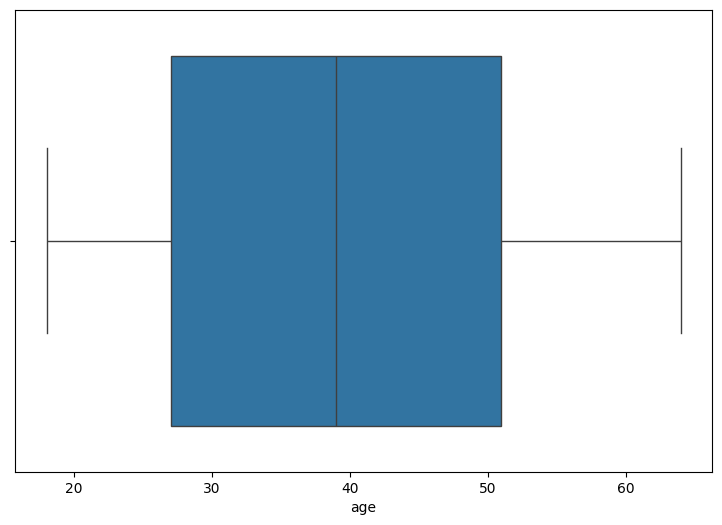

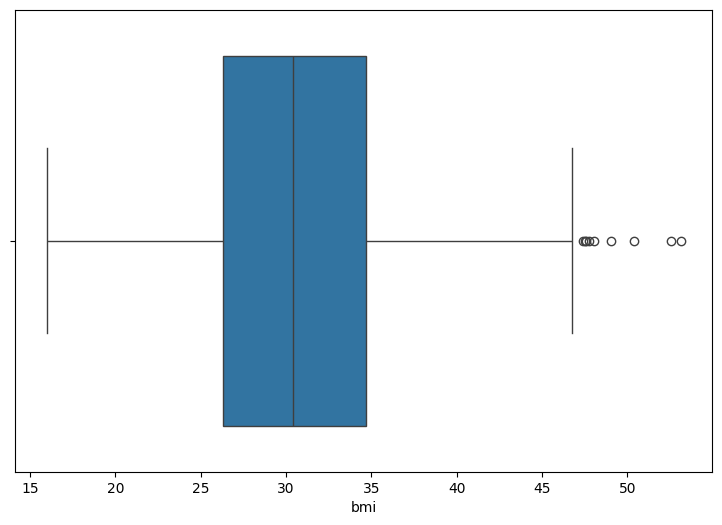

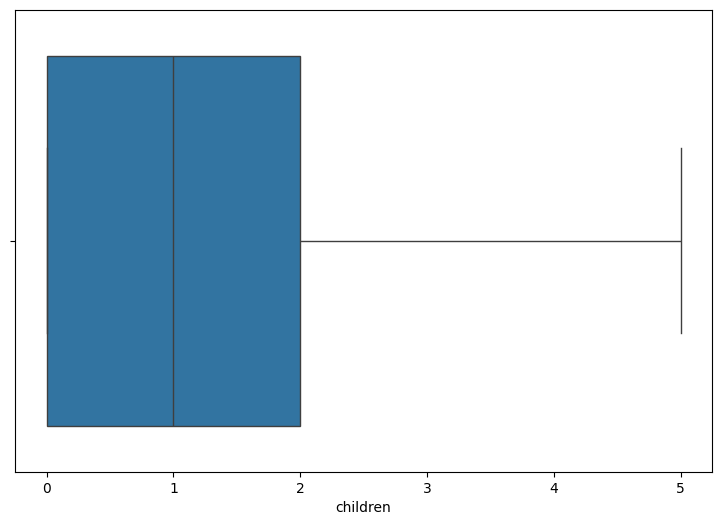

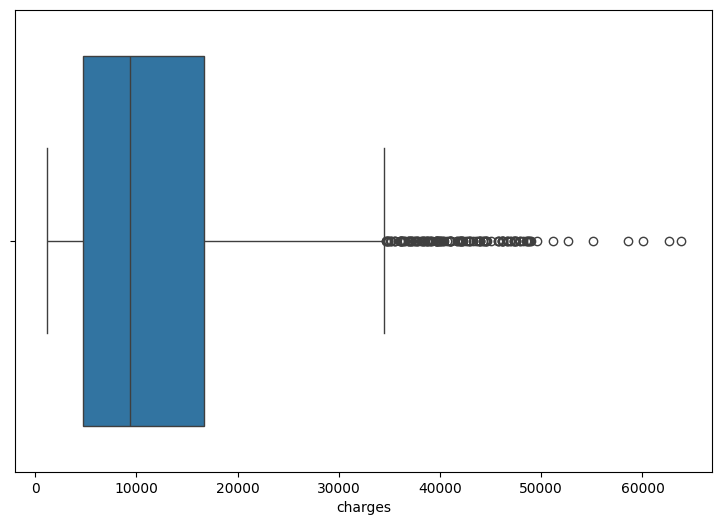

In [16]:
for col in numeric_cols:
  plt.figure(figsize=(9,6))
  sns.boxplot(x=df[col])

<Axes: >

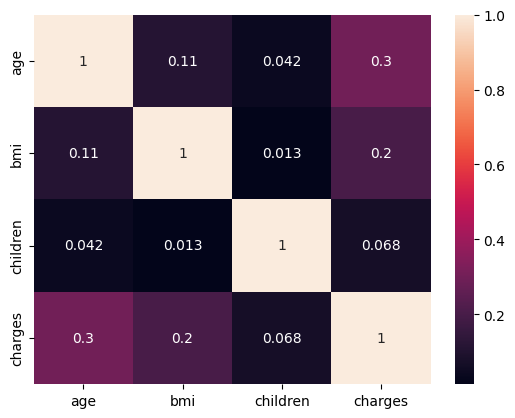

In [17]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

# **DataCleaning and preprocessing**

In [18]:
df_clean=df.copy()

In [19]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [20]:
df_clean.drop_duplicates(inplace=True)

In [21]:
df_clean.shape

(1337, 7)

In [22]:
df_clean['sex'].value_counts()

,count
sex,
male,675
female,662


Here both males and females are under same cateory
suppose if some males are stored as "Male" ,"male","M","m" then it creates multiple entries for each one then we need to again filter them , but in this case that is not there , we can check the same every feature


In [23]:
df_clean['smoker'].value_counts()

,count
smoker,
no,1063
yes,274


In [24]:
df_clean['sex']=df_clean['sex'].map({'male':0,'female':1})
df_clean['smoker']=df_clean['smoker'].map({"no":0,"yes":1})

Here Label encoding has been done


In [25]:
df_clean.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [26]:
df_clean.rename(columns={
    "sex":"is_female",
    "smoker":"is_smoker"
},inplace=True)

In [27]:
df_clean

,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,northwest,10600.54830
1334,18,1,31.920,0,0,northeast,2205.98080
1335,18,1,36.850,0,0,southeast,1629.83350
1336,21,1,25.800,0,0,southwest,2007.94500


In [28]:
df_clean['region'].value_counts()

,count
region,
southeast,364
southwest,325
northwest,324
northeast,324


In [29]:
df_clean=pd.get_dummies(df_clean,columns=['region'],dtype=int)

In [30]:
df_clean

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,0,0,0,1
1,18,0,33.770,1,0,1725.55230,0,0,1,0
2,28,0,33.000,3,0,4449.46200,0,0,1,0
3,33,0,22.705,0,0,21984.47061,0,1,0,0
4,32,0,28.880,0,0,3866.85520,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,10600.54830,0,1,0,0
1334,18,1,31.920,0,0,2205.98080,1,0,0,0
1335,18,1,36.850,0,0,1629.83350,0,0,1,0
1336,21,1,25.800,0,0,2007.94500,0,0,0,1


## **Feature Engineering and Extraction**

<Axes: xlabel='bmi', ylabel='Count'>

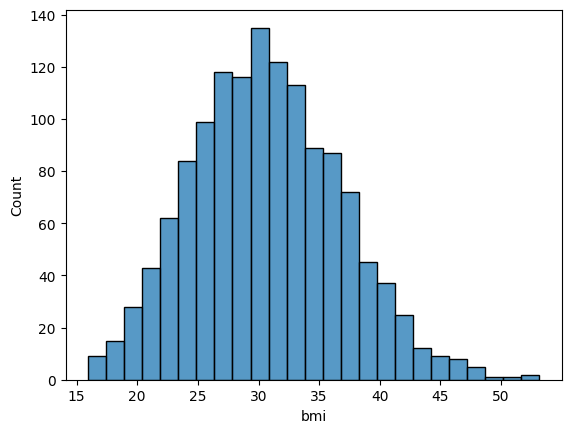

In [31]:
sns.histplot(df_clean['bmi'])

In [32]:
df_clean["bmi_category"]=pd.cut(
    df_clean['bmi'],
    bins=[0,18.5,24.9,29.9,100],
    labels=["underweight","healthy","overweight","obese"]
)

In [33]:
df_clean

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27.900,0,1,16884.92400,0,0,0,1,overweight
1,18,0,33.770,1,0,1725.55230,0,0,1,0,obese
2,28,0,33.000,3,0,4449.46200,0,0,1,0,obese
3,33,0,22.705,0,0,21984.47061,0,1,0,0,healthy
4,32,0,28.880,0,0,3866.85520,0,1,0,0,overweight
...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,10600.54830,0,1,0,0,obese
1334,18,1,31.920,0,0,2205.98080,1,0,0,0,obese
1335,18,1,36.850,0,0,1629.83350,0,0,1,0,obese
1336,21,1,25.800,0,0,2007.94500,0,0,0,1,overweight


In [34]:
df_clean=pd.get_dummies(df_clean,columns=['bmi_category'],dtype=int)

In [35]:
df_clean

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_underweight,bmi_category_healthy,bmi_category_overweight,bmi_category_obese
0,19,1,27.900,0,1,16884.92400,0,0,0,1,0,0,1,0
1,18,0,33.770,1,0,1725.55230,0,0,1,0,0,0,0,1
2,28,0,33.000,3,0,4449.46200,0,0,1,0,0,0,0,1
3,33,0,22.705,0,0,21984.47061,0,1,0,0,0,1,0,0
4,32,0,28.880,0,0,3866.85520,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,10600.54830,0,1,0,0,0,0,0,1
1334,18,1,31.920,0,0,2205.98080,1,0,0,0,0,0,0,1
1335,18,1,36.850,0,0,1629.83350,0,0,1,0,0,0,0,1
1336,21,1,25.800,0,0,2007.94500,0,0,0,1,0,0,1,0


In [36]:
df_clean

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_underweight,bmi_category_healthy,bmi_category_overweight,bmi_category_obese
0,19,1,27.900,0,1,16884.92400,0,0,0,1,0,0,1,0
1,18,0,33.770,1,0,1725.55230,0,0,1,0,0,0,0,1
2,28,0,33.000,3,0,4449.46200,0,0,1,0,0,0,0,1
3,33,0,22.705,0,0,21984.47061,0,1,0,0,0,1,0,0
4,32,0,28.880,0,0,3866.85520,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,10600.54830,0,1,0,0,0,0,0,1
1334,18,1,31.920,0,0,2205.98080,1,0,0,0,0,0,0,1
1335,18,1,36.850,0,0,1629.83350,0,0,1,0,0,0,0,1
1336,21,1,25.800,0,0,2007.94500,0,0,0,1,0,0,1,0


In [37]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scale_cols = ['age', 'bmi', 'children']
df_clean[scale_cols] = scaler.fit_transform(df_clean[scale_cols])

In [39]:
df_clean

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_underweight,bmi_category_healthy,bmi_category_overweight,bmi_category_obese
0,-1.440418,1,-0.453160,-0.909234,1,16884.92400,0,0,0,1,0,0,1,0
1,-1.511647,0,0.509422,-0.079442,0,1725.55230,0,0,1,0,0,0,0,1
2,-0.799350,0,0.383155,1.580143,0,4449.46200,0,0,1,0,0,0,0,1
3,-0.443201,0,-1.305052,-0.909234,0,21984.47061,0,1,0,0,0,1,0,0
4,-0.514431,0,-0.292456,-0.909234,0,3866.85520,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,0.767704,0,0.050269,1.580143,0,10600.54830,0,1,0,0,0,0,0,1
1334,-1.511647,1,0.206053,-0.909234,0,2205.98080,1,0,0,0,0,0,0,1
1335,-1.511647,1,1.014490,-0.909234,0,1629.83350,0,0,1,0,0,0,0,1
1336,-1.297958,1,-0.797524,-0.909234,0,2007.94500,0,0,0,1,0,0,1,0


In [40]:
df_clean.columns

Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northeast', 'region_northwest', 'region_southeast',
       'region_southwest', 'bmi_category_underweight', 'bmi_category_healthy',
       'bmi_category_overweight', 'bmi_category_obese'],
      dtype='object')

In [45]:
df_clean[scale_cols] = scaler.inverse_transform(df_clean[scale_cols])

In [46]:
df_clean

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_underweight,bmi_category_healthy,bmi_category_overweight,bmi_category_obese,charges_bin
0,19.0,1,27.900,0.0,1,16884.92400,0,0,0,1,0,0,1,0,3
1,18.0,0,33.770,1.0,0,1725.55230,0,0,1,0,0,0,0,1,0
2,28.0,0,33.000,3.0,0,4449.46200,0,0,1,0,0,0,0,1,0
3,33.0,0,22.705,0.0,0,21984.47061,0,1,0,0,0,1,0,0,3
4,32.0,0,28.880,0.0,0,3866.85520,0,1,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50.0,0,30.970,3.0,0,10600.54830,0,1,0,0,0,0,0,1,2
1334,18.0,1,31.920,0.0,0,2205.98080,1,0,0,0,0,0,0,1,0
1335,18.0,1,36.850,0.0,0,1629.83350,0,0,1,0,0,0,0,1,0
1336,21.0,1,25.800,0.0,0,2007.94500,0,0,0,1,0,0,1,0,0


In [47]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression



In [49]:
x=df_clean.drop('charges',axis=1)
y=df_clean['charges']

In [51]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)
scaler3=StandardScaler()
x_train=scaler3.fit_transform(x_train)
x_test=scaler3.transform(x_test)


In [54]:
linear=LinearRegression()
linear.fit(x_train,y_train)
y_pred=linear.predict(x_test)

In [57]:
from sklearn.metrics import r2_score
r=r2_score(y_test,y_pred)
n=x_test.shape[0]
p=x_test.shape[1]
adj_r=1-(1-r)*(n-1)/(n-p-1)
adj_r


0.8157465201950136

In [60]:
from sklearn.model_selection import cross_val_score
scores=cross_val_score(
    linear,
    x_train,
    y_train,
    cv=5,
    scoring="r2"
)
scores.mean()


np.float64(0.8165501501821056)